# **APE 03 Grupo D**
-----------------
# **Integrantes:**

*   Noelia Bustan
*   Alison Tapia
*   Cristofer Pineda
*   Elian Jimenez
*   Yimmy Angulo
-----------------

# **Pasos A Realizar**
# 0. **Importar Librerias**

In [ ]:
# ==============================
# CONFIGURACIÓN
# ==============================

import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import randint, norm, binom, uniform
import seaborn as sns

# Configuracion de estilo
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (12, 5)
plt.rcParams["font.size"] = 11

print("Entorno configurado correctamente")

Entorno configurado correctamente


#**1. Caso Discreto (Lanzamiento de Dado):** Definir la PMF para un dado justo, generar su CDF y calcular probabilidades específicas como $P(X \leq 3)$ y $P(2 \leq X \leq 5)$

Valores de X: [1 2 3 4 5 6]
PMF p(x): [0.16666667 0.16666667 0.16666667 0.16666667 0.16666667 0.16666667]
Suma de probabilidades: 0.9999999999999999
 
P(X = 4) = 0.1667
 
P(X <= 3) = 0.5000
 
P(2 <= X <= 5) = 0.6667
 


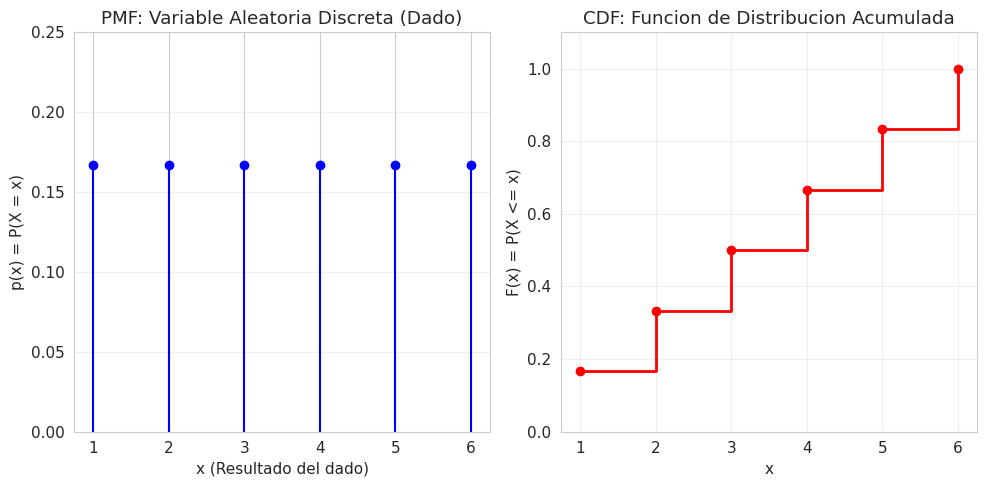

In [ ]:
# ==============================
# DADO JUSTO
# ==============================

# Variable aleatoria: resultado de un dado
# X puede tomar valores: 1, 2, 3, 4, 5, 6

# Valores posibles
x_valores = np.array([1, 2, 3, 4, 5, 6])

# PMF: cada valor tiene probabilidad 1/6
pmf_dado = np.array([1/6, 1/6, 1/6, 1/6, 1/6, 1/6])

print("Valores de X:", x_valores)
print("PMF p(x):", pmf_dado)
print("Suma de probabilidades:", np.sum(pmf_dado))
print(" ");
# a) P(X = 4)
prob_4 = pmf_dado[x_valores == 4][0]
print(f"P(X = 4) = {prob_4:.4f}")
print(" ");
# b) P(X <= 3) usando CDF
prob_menor_3 = cdf_dado[x_valores == 3][0]
print(f"P(X <= 3) = {prob_menor_3:.4f}")
print(" ");
# c) P(2 <= X <= 5)
prob_entre_2_5 = cdf_dado[x_valores == 5][0] - cdf_dado[x_valores == 1][0]
print(f"P(2 <= X <= 5) = {prob_entre_2_5:.4f}")
print(" ");
# Visualizacion de la PMF
plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)
plt.stem(x_valores, pmf_dado, basefmt=" ", linefmt='b-', markerfmt='bo')
plt.xlabel('x (Resultado del dado)')
plt.ylabel('p(x) = P(X = x)')
plt.title('PMF: Variable Aleatoria Discreta (Dado)')
plt.xticks(x_valores)
plt.ylim(0, 0.25)
plt.grid(axis='y', alpha=0.3)

# CDF
cdf_dado = np.cumsum(pmf_dado)
plt.subplot(1, 2, 2)
plt.step(x_valores, cdf_dado, where='post', color='red', linewidth=2)
plt.scatter(x_valores, cdf_dado, color='red', zorder=5)
plt.xlabel('x')
plt.ylabel('F(x) = P(X <= x)')
plt.title('CDF: Funcion de Distribucion Acumulada')
plt.xticks(x_valores)
plt.ylim(0, 1.1)
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()


# **2. Caso Continuo (Servidor Web):** Modelar el tiempo de respuesta ($\mu = 200$, $\sigma = 30$) mediante una distribución normal. Calcular el percentil 95 de la operación.

P(X <= 180) = 0.2525 (25.25%)
 
P(X > 250) = 0.0478 (4.78%)
 
P(170 <= X <= 230) = 0.6827 (68.27%)
 

Percentil 95: 249.35 ms
El 95% de los tiempos de respuesta son menores a 249.35 ms
 


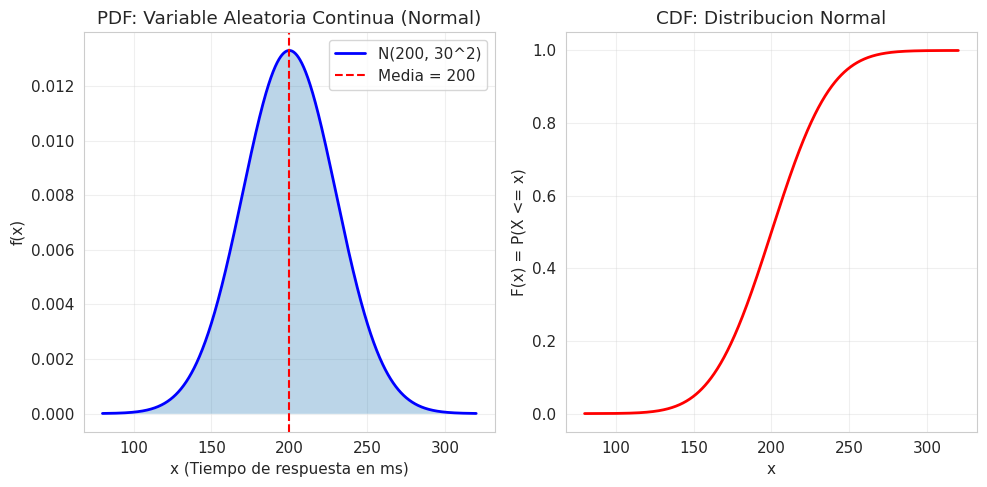

In [ ]:
# ==============================
# DISTRIBUCIÓN NORMAL
# ==============================

# Parametros de la distribucion normal
mu = 200  # media
sigma = 30  # desviacion estandar

# Crear la distribucion
dist_normal = norm(loc=mu, scale=sigma)

# Rango de valores para graficar
x = np.linspace(mu - 4*sigma, mu + 4*sigma, 1000)

# PDF
pdf_normal = dist_normal.pdf(x)

# a) P(X <= 180)
prob_menor_180 = dist_normal.cdf(180)
print(f"P(X <= 180) = {prob_menor_180:.4f} ({prob_menor_180*100:.2f}%)")
print(" ")
# b) P(X > 250)
prob_mayor_250 = 1 - dist_normal.cdf(250)
print(f"P(X > 250) = {prob_mayor_250:.4f} ({prob_mayor_250*100:.2f}%)")
print(" ")
# c) P(170 <= X <= 230)
prob_entre = dist_normal.cdf(230) - dist_normal.cdf(170)
print(f"P(170 <= X <= 230) = {prob_entre:.4f} ({prob_entre*100:.2f}%)")
print(" ")
# d) Percentil 95
p95 = dist_normal.ppf(0.95)
print(f"\nPercentil 95: {p95:.2f} ms")
print(f"El 95% de los tiempos de respuesta son menores a {p95:.2f} ms")
print(" ")
# Visualizacion
plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)
plt.plot(x, pdf_normal, 'b-', linewidth=2, label=f'N({mu}, {sigma}^2)')
plt.fill_between(x, pdf_normal, alpha=0.3)
plt.axvline(mu, color='red', linestyle='--', label=f'Media = {mu}')
plt.xlabel('x (Tiempo de respuesta en ms)')
plt.ylabel('f(x)')
plt.title('PDF: Variable Aleatoria Continua (Normal)')
plt.legend()
plt.grid(alpha=0.3)

# CDF
cdf_normal = dist_normal.cdf(x)
plt.subplot(1, 2, 2)
plt.plot(x, cdf_normal, 'r-', linewidth=2)
plt.xlabel('x')
plt.ylabel('F(x) = P(X <= x)')
plt.title('CDF: Distribucion Normal')
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()


#**3. Análisis Comparativo:** Crear una visualización dual que permita contrastar el concepto de "probabilidad en puntos específicos" (discreta) vs. "área bajo la curva" (continua).

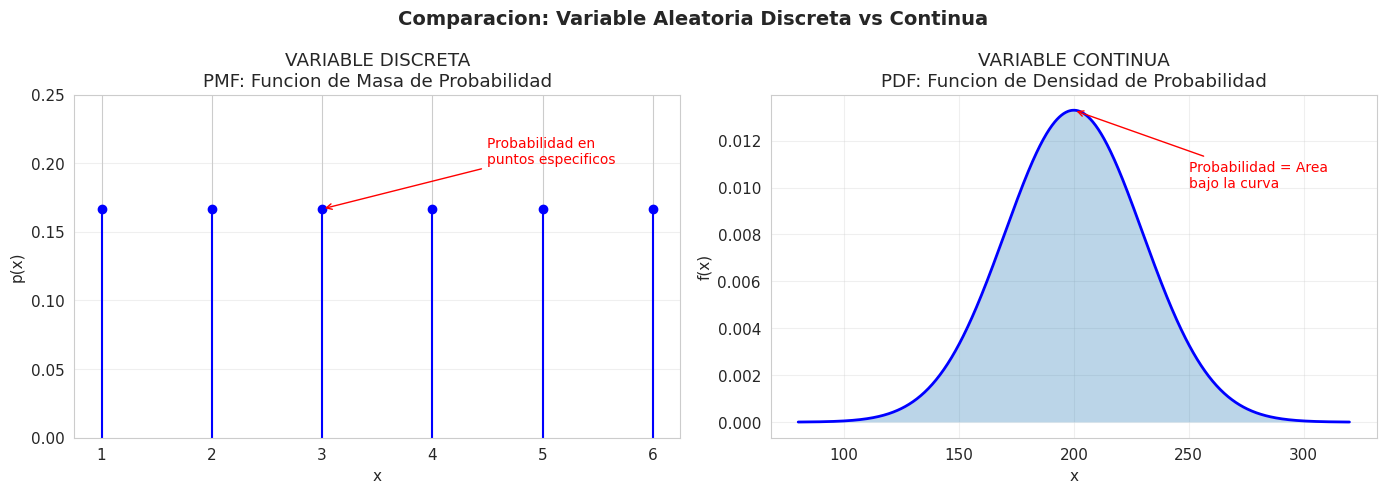

In [ ]:
# ==============================
# COMPARACIÓN
# ==============================

# Comparacion PMF vs PDF
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Variable Discreta (Dado)
axes[0].stem(x_valores, pmf_dado, basefmt=" ", linefmt='b-', markerfmt='bo')
axes[0].set_xlabel('x')
axes[0].set_ylabel('p(x)')
axes[0].set_title('VARIABLE DISCRETA\nPMF: Funcion de Masa de Probabilidad')
axes[0].set_xticks(x_valores)
axes[0].set_ylim(0, 0.25)
axes[0].grid(axis='y', alpha=0.3)

# Anotaciones
axes[0].annotate('Probabilidad en\npuntos especificos', xy=(3, 1/6), xytext=(4.5, 0.2),
                 arrowprops=dict(arrowstyle='->', color='red'),
                 fontsize=10, color='red')

# Variable Continua (Normal)
axes[1].plot(x, pdf_normal, 'b-', linewidth=2)
axes[1].fill_between(x, pdf_normal, alpha=0.3)
axes[1].set_xlabel('x')
axes[1].set_ylabel('f(x)')
axes[1].set_title('VARIABLE CONTINUA\nPDF: Funcion de Densidad de Probabilidad')
axes[1].grid(alpha=0.3)

# Anotaciones
axes[1].annotate('Probabilidad = Area\nbajo la curva', xy=(200, norm.pdf(200, 200, 30)), xytext=(250, 0.01),
                 arrowprops=dict(arrowstyle='->', color='red'),
                 fontsize=10, color='red')

plt.suptitle('Comparacion: Variable Aleatoria Discreta vs Continua', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


# **4. Identificación en el Campus:** Registrar 5 variables aleatorias observadas en áreas de la UNL (Biblioteca, Cafetería, etc.), clasificándolas por tipo y distribución esperada.

In [ ]:
# ==============================
# VARIABLES UNL
# ==============================

variables_unl = [
    {
        'Nombre': 'Tiempo de espera en la fila del bar',
        'Ubicacion': 'Cafeteria central',
        'Tipo': 'Continua',
        'Valores_Posibles': '0 a 15 minutos',
        'Distribucion_Esperada': 'Exponencial o Normal'
    },
    {
        'Nombre': 'Uso de laboratorio (sí/no)',
        'Ubicacion': 'Laboratorio de computación',
        'Tipo': 'Discreta',
        'Valores_Posibles': '0 = no, 1 = sí',
        'Distribucion_Esperada': 'Bernoulli'
    },
    {
        'Nombre': 'Número de tutorías asistidas',
        'Ubicacion': 'Virtual',
        'Tipo': 'Discreta',
        'Valores_Posibles': '0 a 5 tutorías',
        'Distribucion_Esperada': 'Binomial'
    },
    {
        'Nombre': 'Personas que usan la cancha por hora',
        'Ubicacion': 'Canchas deportivas',
        'Tipo': 'Discreta',
        'Valores_Posibles': '0 a 20 personas',
        'Distribucion_Esperada': 'Binomial'
    },
    {
        'Nombre': 'Velocidad de descarga (Mbps)',
        'Ubicacion': 'Red WiFi del campus',
        'Tipo': 'Continua',
        'Valores_Posibles': '20 a 80 Mbps (aprox)',
        'Distribucion_Esperada': 'Normal'
    },
    {
        'Nombre': 'Tiempo de permanencia de vehículos',
        'Ubicacion': 'Parqueadero',
        'Tipo': 'Continua',
        'Valores_Posibles': '0 a 6 horas',
        'Distribucion_Esperada': 'Normal'
    }
]

# ==============================
# TABLA (VERSIÓN BONITA)
# ==============================

import pandas as pd

df = pd.DataFrame(variables_unl)

df

,Nombre,Ubicacion,Tipo,Valores_Posibles,Distribucion_Esperada
0,Tiempo de espera en la fila del bar,Cafeteria central,Continua,0 a 15 minutos,Exponencial o Normal
1,Uso de laboratorio (sí/no),Laboratorio de computación,Discreta,"0 = no, 1 = sí",Bernoulli
2,Número de tutorías asistidas,Virtual,Discreta,0 a 5 tutorías,Binomial
3,Personas que usan la cancha por hora,Canchas deportivas,Discreta,0 a 20 personas,Binomial
4,Velocidad de descarga (Mbps),Red WiFi del campus,Continua,20 a 80 Mbps (aprox),Normal
5,Tiempo de permanencia de vehículos,Parqueadero,Continua,0 a 6 horas,Normal


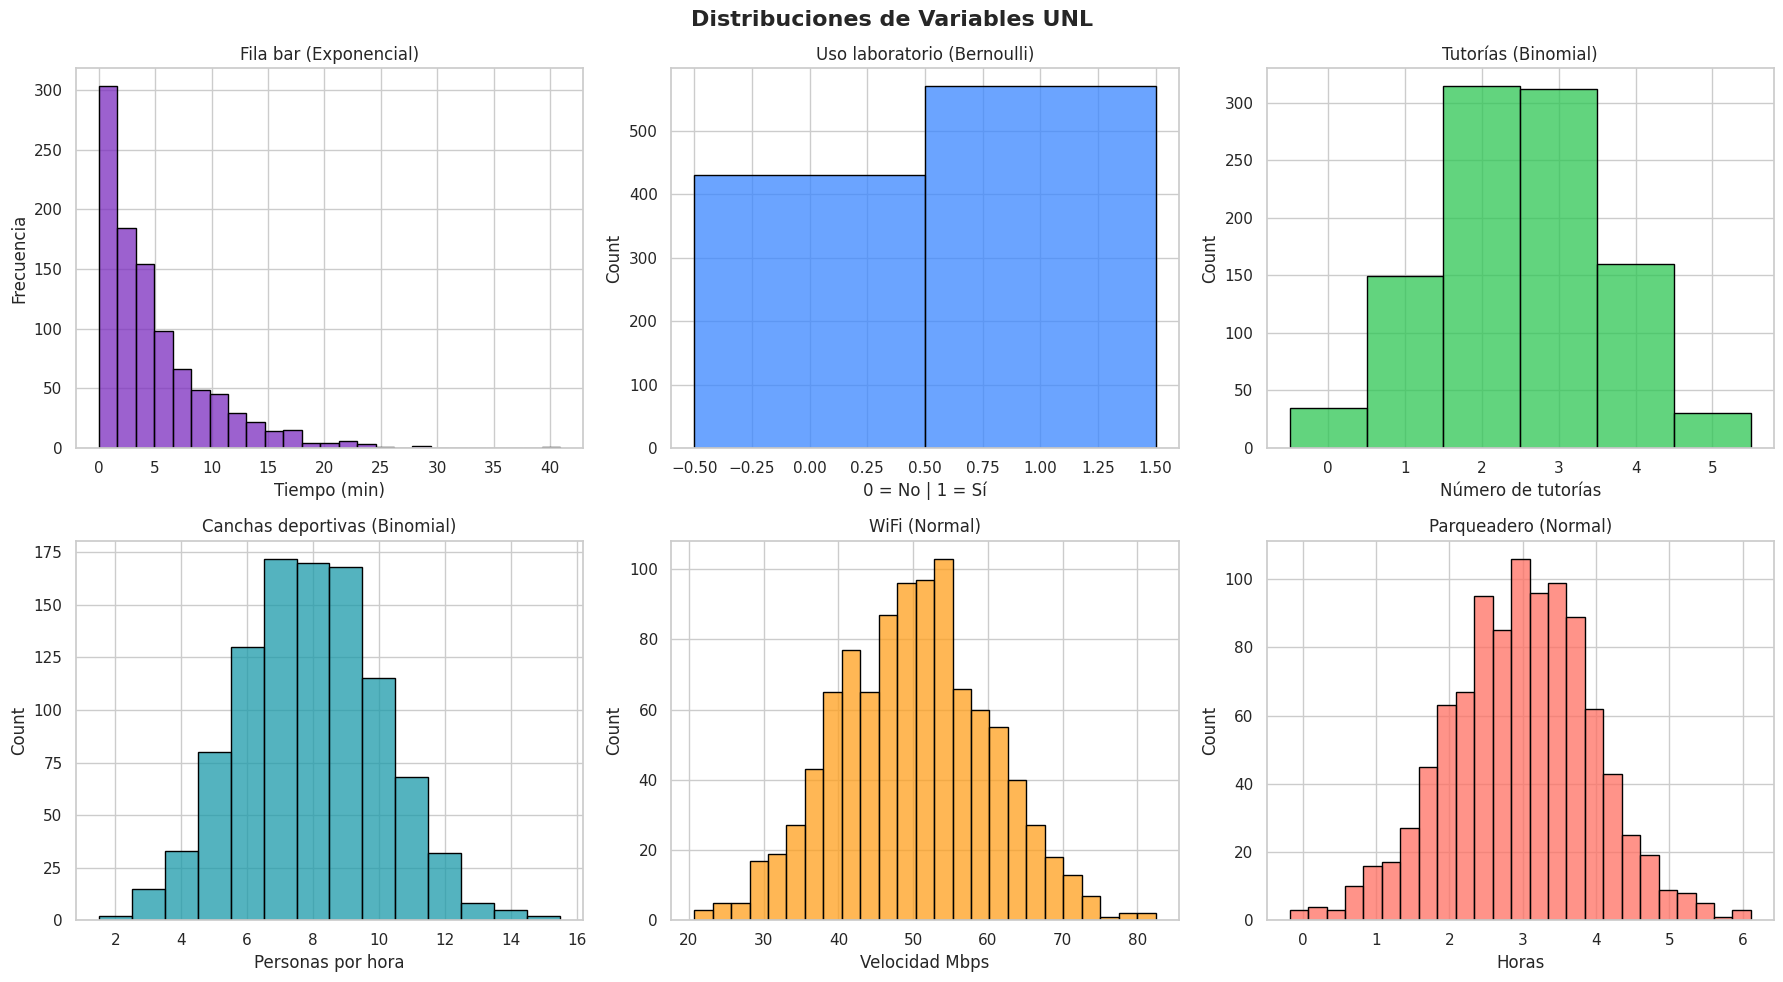

In [ ]:
# ==============================
# GRÁFICAS ESTÉTICAS SIN KDE
# ==============================

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

np.random.seed(42)

# Estilo limpio
sns.set(style="whitegrid")

n = 1000

# ==============================
# SIMULACIÓN DE DATOS
# ==============================

fila_bar = np.random.exponential(scale=5, size=n)   # Exponencial
lab = np.random.binomial(1, 0.6, size=n)            # Bernoulli
tutorias = np.random.binomial(5, 0.5, size=n)       # Binomial
canchas = np.random.binomial(20, 0.4, size=n)       # Binomial
wifi = np.random.normal(50, 10, size=n)             # Normal
parqueo = np.random.normal(3, 1, size=n)            # Normal

# ==============================
# GRÁFICOS
# ==============================

fig, axes = plt.subplots(2, 3, figsize=(18, 10))

# Exponencial
sns.histplot(fila_bar, bins=25, color="#7B2CBF", edgecolor="black", ax=axes[0,0])
axes[0,0].set_title("Fila bar (Exponencial)")
axes[0,0].set_xlabel("Tiempo (min)")
axes[0,0].set_ylabel("Frecuencia")

# Bernoulli
sns.histplot(lab, discrete=True, color="#3A86FF", edgecolor="black", ax=axes[0,1])
axes[0,1].set_title("Uso laboratorio (Bernoulli)")
axes[0,1].set_xlabel("0 = No | 1 = Sí")

# Binomial (tutorías)
sns.histplot(tutorias, discrete=True, color="#2DC653", edgecolor="black", ax=axes[0,2])
axes[0,2].set_title("Tutorías (Binomial)")
axes[0,2].set_xlabel("Número de tutorías")

# Binomial (canchas)
sns.histplot(canchas, discrete=True, color="#1B9AAA", edgecolor="black", ax=axes[1,0])
axes[1,0].set_title("Canchas deportivas (Binomial)")
axes[1,0].set_xlabel("Personas por hora")

# Normal (WiFi)
sns.histplot(wifi, bins=25, color="#FF9F1C", edgecolor="black", ax=axes[1,1])
axes[1,1].set_title("WiFi (Normal)")
axes[1,1].set_xlabel("Velocidad Mbps")

# Normal (Parqueadero)
sns.histplot(parqueo, bins=25, color="#FF6F61", edgecolor="black", ax=axes[1,2])
axes[1,2].set_title("Parqueadero (Normal)")
axes[1,2].set_xlabel("Horas")

# Título general
plt.suptitle("Distribuciones de Variables UNL", fontsize=16, fontweight="bold")

plt.tight_layout()
plt.show()

#**Trabajo Autonomo: Yimmy Angulo**

In [ ]:
# ==============================
# IMPORTACIONES
# ==============================

import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import binom

# ==============================
# PARTE 1: DEFINICIÓN DEL MODELO
# ==============================

# Contexto:
# X = número de días que un estudiante llega tarde en 12 días

n = 12   # número total de días (ensayos)
p = 0.3  # probabilidad de llegar tarde en un día

# Generamos todos los valores posibles de la variable aleatoria
# (puede llegar tarde desde 0 hasta 12 días)
x = np.arange(0, n+1)

# ==============================
# CÁLCULO DE FUNCIONES
# ==============================

# PMF: Probabilidad de cada valor exacto P(X = x)
pmf = binom.pmf(x, n, p)

# CDF: Probabilidad acumulada P(X ≤ x)
cdf = binom.cdf(x, n, p)

# ==============================
# MEDIDAS ESTADÍSTICAS
# ==============================

# Media (valor esperado)
media = n * p

# Varianza
varianza = n * p * (1 - p)

# Desviación estándar
desviacion = np.sqrt(varianza)

# Mostrar resultados
print("Valores posibles:", x)
print("PMF:", np.round(pmf, 4))
print("CDF:", np.round(cdf, 4))

print("\nMedia:", round(media,2))
print("Varianza:", round(varianza,2))
print("Desviación estándar:", round(desviacion,2))

Valores posibles: [ 0  1  2  3  4  5  6  7  8  9 10 11 12]
PMF: [1.380e-02 7.120e-02 1.678e-01 2.397e-01 2.311e-01 1.585e-01 7.920e-02
 2.910e-02 7.800e-03 1.500e-03 2.000e-04 0.000e+00 0.000e+00]
CDF: [0.0138 0.085  0.2528 0.4925 0.7237 0.8822 0.9614 0.9905 0.9983 0.9998
 1.     1.     1.    ]

Media: 3.6
Varianza: 2.52
Desviación estándar: 1.59


In [ ]:
# ==============================
# PARTE 2: CÁLCULO DE PROBABILIDADES
# ==============================

# 1. Probabilidad exacta: exactamente 3 días tarde
p1 = binom.pmf(3, n, p)

# 2. Probabilidad acumulada: hasta 4 días tarde
p2 = binom.cdf(4, n, p)

# 3. Probabilidad en intervalo: entre 3 y 6 días
p3 = binom.cdf(6, n, p) - binom.cdf(2, n, p)

# 4. Probabilidad de valores altos: 6 o más días
p4 = 1 - binom.cdf(5, n, p)

# 5. Probabilidad de no llegar tarde nunca
p5 = binom.pmf(0, n, p)

# 6. Probabilidad de llegar tarde al menos una vez
p6 = 1 - p5

# 7. Probabilidad de eventos extremos (9 a 12 días)
p7 = binom.cdf(12, n, p) - binom.cdf(8, n, p)

# 8. Probabilidad alrededor de la media (4 a 5 días)
p8 = binom.cdf(5, n, p) - binom.cdf(3, n, p)

# Mostrar resultados
print("\n--- PROBABILIDADES ---")
print(f"P(X = 3) = {p1:.4f}")
print(f"P(X ≤ 4) = {p2:.4f}")
print(f"P(3 ≤ X ≤ 6) = {p3:.4f}")
print(f"P(X ≥ 6) = {p4:.4f}")
print(f"P(X = 0) = {p5:.4f}")
print(f"P(X ≥ 1) = {p6:.4f}")
print(f"P(9 ≤ X ≤ 12) = {p7:.4f}")
print(f"P(4 ≤ X ≤ 5) = {p8:.4f}")


--- PROBABILIDADES ---
P(X = 3) = 0.2397
P(X ≤ 4) = 0.7237
P(3 ≤ X ≤ 6) = 0.7086
P(X ≥ 6) = 0.1178
P(X = 0) = 0.0138
P(X ≥ 1) = 0.9862
P(9 ≤ X ≤ 12) = 0.0017
P(4 ≤ X ≤ 5) = 0.3896


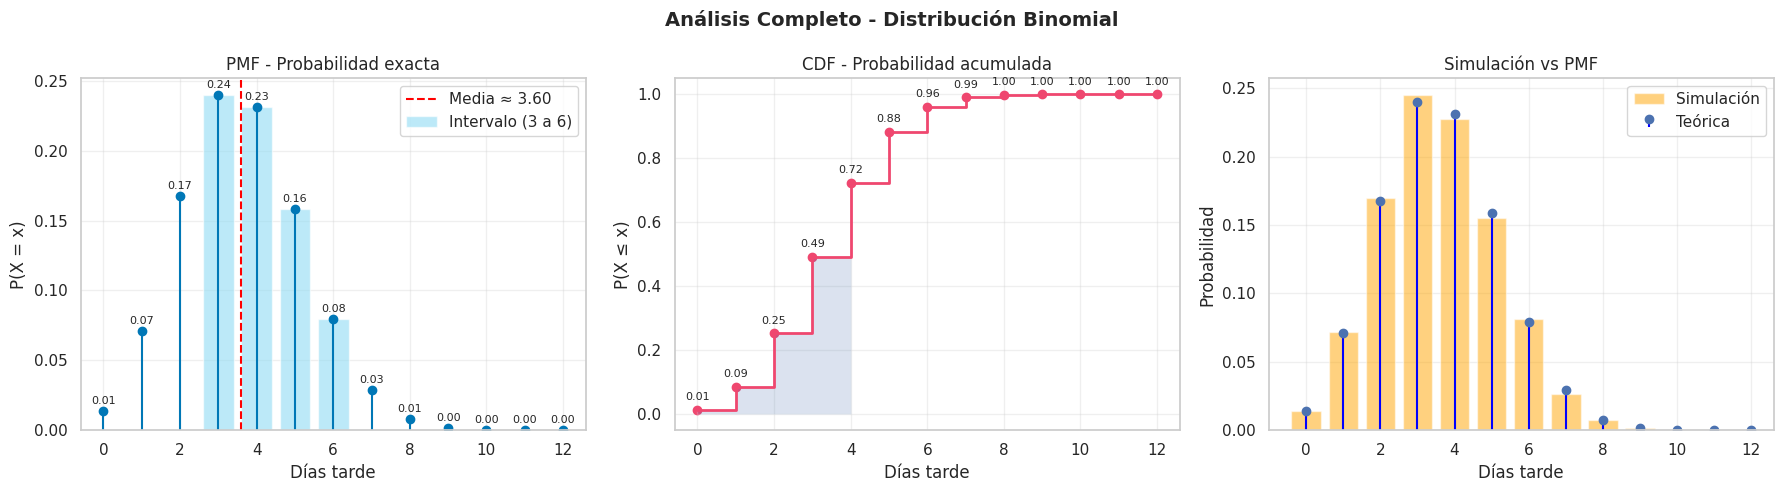

In [ ]:
# ==============================
# GRÁFICAS UNIFICADAS
# ==============================

# Creamos una figura con 3 subgráficos en una fila
fig, axes = plt.subplots(1, 3, figsize=(18,5))

# ==============================
# 1. PMF
# ==============================

axes[0].stem(x, pmf, basefmt=" ", linefmt='#0077b6', markerfmt='o')

# Línea de la media
axes[0].axvline(media, color='red', linestyle='--', label=f"Media ≈ {media:.2f}")

# Resaltar intervalo importante
mask = (x >= 3) & (x <= 6)
axes[0].bar(x[mask], pmf[mask], color='#90dbf4', alpha=0.6, label="Intervalo (3 a 6)")

axes[0].set_title("PMF - Probabilidad exacta")
axes[0].set_xlabel("Días tarde")
axes[0].set_ylabel("P(X = x)")
axes[0].grid(alpha=0.3)
axes[0].legend()

# Etiquetas
for i, v in enumerate(pmf):
    axes[0].text(x[i], v+0.005, f"{v:.2f}", ha='center', fontsize=8)


# ==============================
# 2. CDF
# ==============================

axes[1].step(x, cdf, where='post', color='#ef476f', linewidth=2)
axes[1].scatter(x, cdf, color='#ef476f')

# Área acumulada destacada
axes[1].fill_between(x[x<=4], cdf[x<=4], step='post', alpha=0.2)

axes[1].set_title("CDF - Probabilidad acumulada")
axes[1].set_xlabel("Días tarde")
axes[1].set_ylabel("P(X ≤ x)")
axes[1].grid(alpha=0.3)

# Etiquetas
for i, v in enumerate(cdf):
    axes[1].text(x[i], v+0.03, f"{v:.2f}", ha='center', fontsize=8)


# ==============================
# 3. SIMULACIÓN vs TEÓRICA
# ==============================

axes[2].bar(valores, freq, alpha=0.5, color='orange', label="Simulación")
axes[2].stem(x, pmf, basefmt=" ", linefmt='blue', markerfmt='bo', label="Teórica")

axes[2].set_title("Simulación vs PMF")
axes[2].set_xlabel("Días tarde")
axes[2].set_ylabel("Probabilidad")
axes[2].grid(alpha=0.3)
axes[2].legend()


# ==============================
# TÍTULO GENERAL
# ==============================

plt.suptitle("Análisis Completo - Distribución Binomial", fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

## Interpretación de resultados

La variable representa el número de días en los que un estudiante llega tarde durante un periodo de 12 días. La media obtenida indica que, en promedio, el estudiante llega tarde aproximadamente 3.6 días, lo cual coincide con los valores de mayor probabilidad observados en la PMF.

Las probabilidades calculadas permiten analizar distintos escenarios, como eventos exactos, acumulados e intervalos. Se observa que los valores cercanos a la media tienen mayor probabilidad, mientras que los extremos son menos frecuentes.

El gráfico de la CDF muestra cómo la probabilidad se acumula progresivamente, facilitando la interpretación de eventos como "llegar tarde hasta cierto número de días".

Finalmente, la simulación valida el modelo teórico, ya que los resultados obtenidos experimentalmente se aproximan a las probabilidades calculadas mediante la distribución binomial.

# **Trabajo Autonomo: Noelia Busan**

Valores posibles: [ 0  1  2  3  4  5  6  7  8  9 10]
PMF: [1.000e-04 1.600e-03 1.060e-02 4.250e-02 1.115e-01 2.007e-01 2.508e-01
 2.150e-01 1.209e-01 4.030e-02 6.000e-03]
CDF: [1.000e-04 1.700e-03 1.230e-02 5.480e-02 1.662e-01 3.669e-01 6.177e-01
 8.327e-01 9.536e-01 9.940e-01 1.000e+00]

Media: 6.0
Varianza: 2.4
Desviación estándar: 1.55


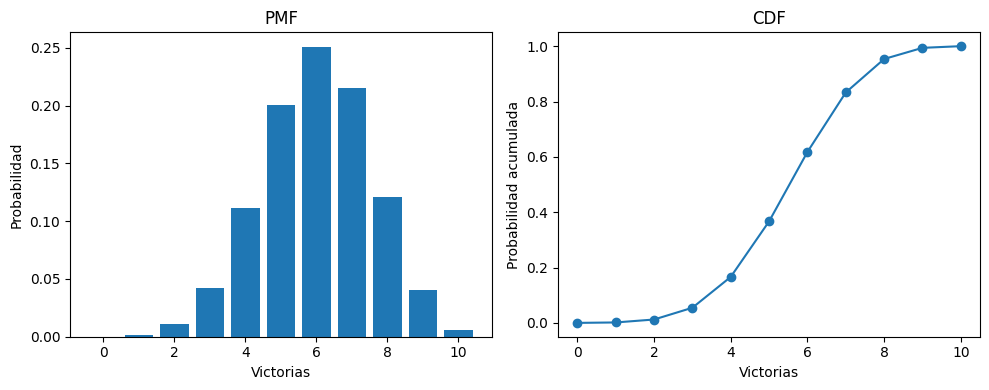

In [ ]:
# Contexto:
# X = número de veces que un jugador gana en 10 partidas

import numpy as np
from scipy.stats import binom
import matplotlib.pyplot as plt

n = 10   # número de partidas
p = 0.6  # probabilidad de ganar una partida

x = np.arange(0, n+1)

pmf = binom.pmf(x, n, p)
cdf = binom.cdf(x, n, p)

media = n * p
varianza = n * p * (1 - p)
desviacion = np.sqrt(varianza)

print("Valores posibles:", x)
print("PMF:", np.round(pmf, 4))
print("CDF:", np.round(cdf, 4))

print("\nMedia:", round(media,2))
print("Varianza:", round(varianza,2))
print("Desviación estándar:", round(desviacion,2))

plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
plt.bar(x, pmf)
plt.title("PMF")
plt.xlabel("Victorias")
plt.ylabel("Probabilidad")

plt.subplot(1,2,2)
plt.plot(x, cdf, marker='o')
plt.title("CDF")
plt.xlabel("Victorias")
plt.ylabel("Probabilidad acumulada")

plt.tight_layout()
plt.show()

In [ ]:
# ==============================
# PARTE 2: CÁLCULO DE PROBABILIDADES
# ==============================

# 1. Probabilidad exacta: exactamente 6 victorias
p1 = binom.pmf(6, n, p)

# 2. Probabilidad acumulada: hasta 5 victorias
p2 = binom.cdf(5, n, p)

# 3. Probabilidad en intervalo: entre 4 y 7 victorias
p3 = binom.cdf(7, n, p) - binom.cdf(3, n, p)

# 4. Probabilidad de valores altos: 7 o más victorias
p4 = 1 - binom.cdf(6, n, p)

# 5. Probabilidad de no ganar ninguna partida
p5 = binom.pmf(0, n, p)

# 6. Probabilidad de ganar al menos una vez
p6 = 1 - p5

# 7. Probabilidad de resultados extremos (9 a 10 victorias)
p7 = binom.cdf(10, n, p) - binom.cdf(8, n, p)

# 8. Probabilidad alrededor de la media (5 a 7 victorias)
p8 = binom.cdf(7, n, p) - binom.cdf(4, n, p)

# ==============================
# RESULTADOS
# ==============================

print("\n--- PROBABILIDADES ---")
print(f"P(X = 6) = {p1:.4f}")
print(f"P(X ≤ 5) = {p2:.4f}")
print(f"P(4 ≤ X ≤ 7) = {p3:.4f}")
print(f"P(X ≥ 7) = {p4:.4f}")
print(f"P(X = 0) = {p5:.4f}")
print(f"P(X ≥ 1) = {p6:.4f}")
print(f"P(9 ≤ X ≤ 10) = {p7:.4f}")
print(f"P(5 ≤ X ≤ 7) = {p8:.4f}")


--- PROBABILIDADES ---
P(X = 6) = 0.2508
P(X ≤ 5) = 0.3669
P(4 ≤ X ≤ 7) = 0.7779
P(X ≥ 7) = 0.3823
P(X = 0) = 0.0001
P(X ≥ 1) = 0.9999
P(9 ≤ X ≤ 10) = 0.0464
P(5 ≤ X ≤ 7) = 0.6665


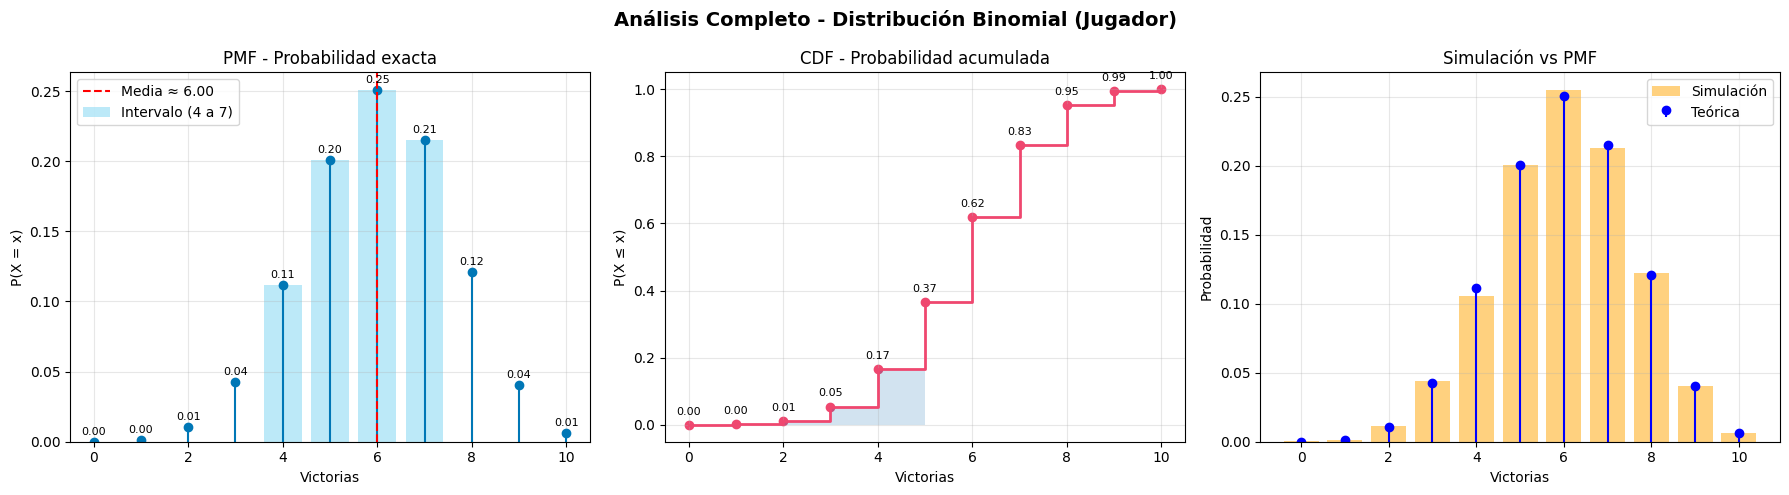

In [ ]:
# ==============================
# PARTE 3: SIMULACIÓN
# ==============================

# Simulamos 10,000 experimentos
simulaciones = 10000
datos = np.random.binomial(n, p, simulaciones)

# Frecuencias relativas
valores, conteos = np.unique(datos, return_counts=True)
freq = conteos / simulaciones


# ==============================
# GRÁFICAS UNIFICADAS
# ==============================

fig, axes = plt.subplots(1, 3, figsize=(18,5))

# ==============================
# 1. PMF
# ==============================

axes[0].stem(x, pmf, basefmt=" ", linefmt='#0077b6', markerfmt='o')

# Línea de la media
axes[0].axvline(media, color='red', linestyle='--', label=f"Media ≈ {media:.2f}")

# Resaltar intervalo importante (4 a 7 victorias)
mask = (x >= 4) & (x <= 7)
axes[0].bar(x[mask], pmf[mask], color='#90dbf4', alpha=0.6, label="Intervalo (4 a 7)")

axes[0].set_title("PMF - Probabilidad exacta")
axes[0].set_xlabel("Victorias")
axes[0].set_ylabel("P(X = x)")
axes[0].grid(alpha=0.3)
axes[0].legend()

for i, v in enumerate(pmf):
    axes[0].text(x[i], v+0.005, f"{v:.2f}", ha='center', fontsize=8)


# ==============================
# 2. CDF
# ==============================

axes[1].step(x, cdf, where='post', color='#ef476f', linewidth=2)
axes[1].scatter(x, cdf, color='#ef476f')

# Área acumulada destacada (hasta 5 victorias)
axes[1].fill_between(x[x<=5], cdf[x<=5], step='post', alpha=0.2)

axes[1].set_title("CDF - Probabilidad acumulada")
axes[1].set_xlabel("Victorias")
axes[1].set_ylabel("P(X ≤ x)")
axes[1].grid(alpha=0.3)

for i, v in enumerate(cdf):
    axes[1].text(x[i], v+0.03, f"{v:.2f}", ha='center', fontsize=8)


# ==============================
# 3. SIMULACIÓN vs TEÓRICA
# ==============================

axes[2].bar(valores, freq, alpha=0.5, color='orange', label="Simulación")
axes[2].stem(x, pmf, basefmt=" ", linefmt='blue', markerfmt='bo', label="Teórica")

axes[2].set_title("Simulación vs PMF")
axes[2].set_xlabel("Victorias")
axes[2].set_ylabel("Probabilidad")
axes[2].grid(alpha=0.3)
axes[2].legend()


# ==============================
# TÍTULO GENERAL
# ==============================

plt.suptitle("Análisis Completo - Distribución Binomial (Jugador)",
             fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

# **Interpretación de los Resultados:**
La variable aleatoria X representa el número de victorias que obtiene un jugador en 10 partidas, donde cada partida tiene una probabilidad de ganar de p=0.6. La media obtenida (μ=6) indica que, en promedio, el jugador gana aproximadamente 6 partidas, lo cual coincide con el valor más probable observado en la PMF.

Al analizar la PMF, se observa que las mayores probabilidades se concentran entre 5 y 7 victorias, lo que significa que es más común que el jugador obtenga resultados cercanos a la media. Esto refleja un comportamiento relativamente estable, donde no hay grandes variaciones extremas. La probabilidad de obtener exactamente 6 victorias es una de las más altas, confirmando que este es el resultado más esperado.

La CDF permite observar cómo se acumulan las probabilidades. Por ejemplo, la probabilidad de ganar hasta 5 partidas es considerable, pero también se nota que existe una probabilidad significativa de obtener más de 6 victorias, lo que indica que el jugador tiene un buen desempeño general. A diferencia de otros casos con probabilidades bajas, aquí la distribución está más equilibrada y centrada.

En cuanto a los eventos extremos, como ganar 9 o 10 partidas, se observa que tienen una probabilidad baja, pero no despreciable. Esto indica que, aunque es poco frecuente, sí es posible que el jugador tenga un rendimiento excepcional.

Finalmente, la simulación confirma el comportamiento teórico de la distribución binomial. Los resultados obtenidos mediante los experimentos simulados se ajustan bastante bien a la PMF, lo que valida el modelo probabilístico utilizado.

# **Trabajo Autonomo: Alison Tapia**

In [ ]:
# Contexto:
# En una rifa hay 100 boletos y solo 1 es ganador.
# Una persona compra 10 boletos.
# X = número de boletos ganadores obtenidos

import numpy as np
from scipy.stats import binom
import matplotlib.pyplot as plt

n = 10       # boletos comprados
p = 1/100    # probabilidad de que un boleto gane

x = np.arange(0, n+1)

pmf = binom.pmf(x, n, p)
cdf = binom.cdf(x, n, p)

media = n * p
varianza = n * p * (1 - p)
desviacion = np.sqrt(varianza)

print("Valores posibles:", x)
print("PMF:", np.round(pmf, 6))
print("CDF:", np.round(cdf, 6))

print("\nMedia:", round(media,4))
print("Varianza:", round(varianza,4))
print("Desviación estándar:", round(desviacion,4))


Valores posibles: [ 0  1  2  3  4  5  6  7  8  9 10]
PMF: [9.04382e-01 9.13520e-02 4.15200e-03 1.12000e-04 2.00000e-06 0.00000e+00
 0.00000e+00 0.00000e+00 0.00000e+00 0.00000e+00 0.00000e+00]
CDF: [0.904382 0.995734 0.999886 0.999998 1.       1.       1.       1.
 1.       1.       1.      ]

Media: 0.1
Varianza: 0.099
Desviación estándar: 0.3146


In [ ]:
# ==============================
# PARTE 2: CÁLCULO DE PROBABILIDADES
# ==============================
pmf = binom.pmf(x, n, p)
cdf = binom.cdf(x, n, p)

media = n * p
varianza = n * p * (1 - p)
desviacion = np.sqrt(varianza)

print("Valores posibles:", x)
print("PMF:", np.round(pmf, 6))
print("CDF:", np.round(cdf, 6))

print("\nMedia:", round(media,4))
print("Varianza:", round(varianza,4))
print("Desviación estándar:", round(desviacion,4))

Valores posibles: [ 0  1  2  3  4  5  6  7  8  9 10]
PMF: [9.04382e-01 9.13520e-02 4.15200e-03 1.12000e-04 2.00000e-06 0.00000e+00
 0.00000e+00 0.00000e+00 0.00000e+00 0.00000e+00 0.00000e+00]
CDF: [0.904382 0.995734 0.999886 0.999998 1.       1.       1.       1.
 1.       1.       1.      ]

Media: 0.1
Varianza: 0.099
Desviación estándar: 0.3146


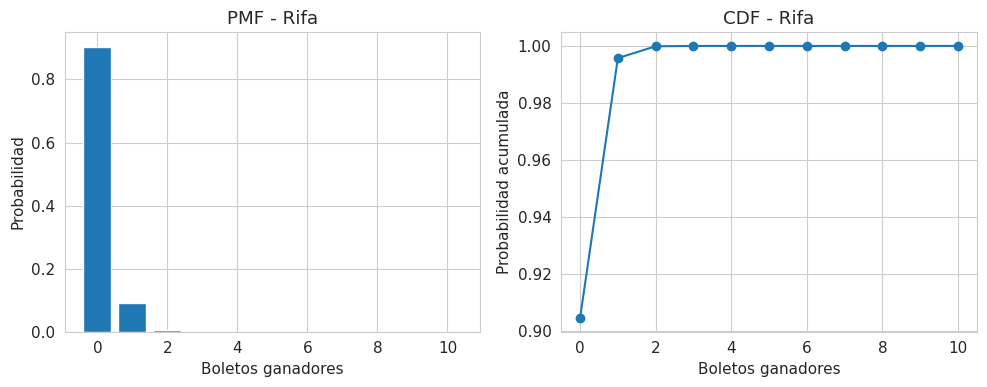

In [ ]:
# ==============================
# GRAFICAS BASICAS
# ==============================
plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
plt.bar(x, pmf)
plt.title("PMF - Rifa")
plt.xlabel("Boletos ganadores")
plt.ylabel("Probabilidad")

plt.subplot(1,2,2)
plt.plot(x, cdf, marker='o')
plt.title("CDF - Rifa")
plt.xlabel("Boletos ganadores")
plt.ylabel("Probabilidad acumulada")

plt.tight_layout()
plt.show()

In [ ]:
# ==============================
# PARTE 3: SIMULACIÓN
# ==============================
simulaciones = 10000
datos = np.random.binomial(n, p, simulaciones)

valores, conteos = np.unique(datos, return_counts=True)
freq = conteos / simulaciones

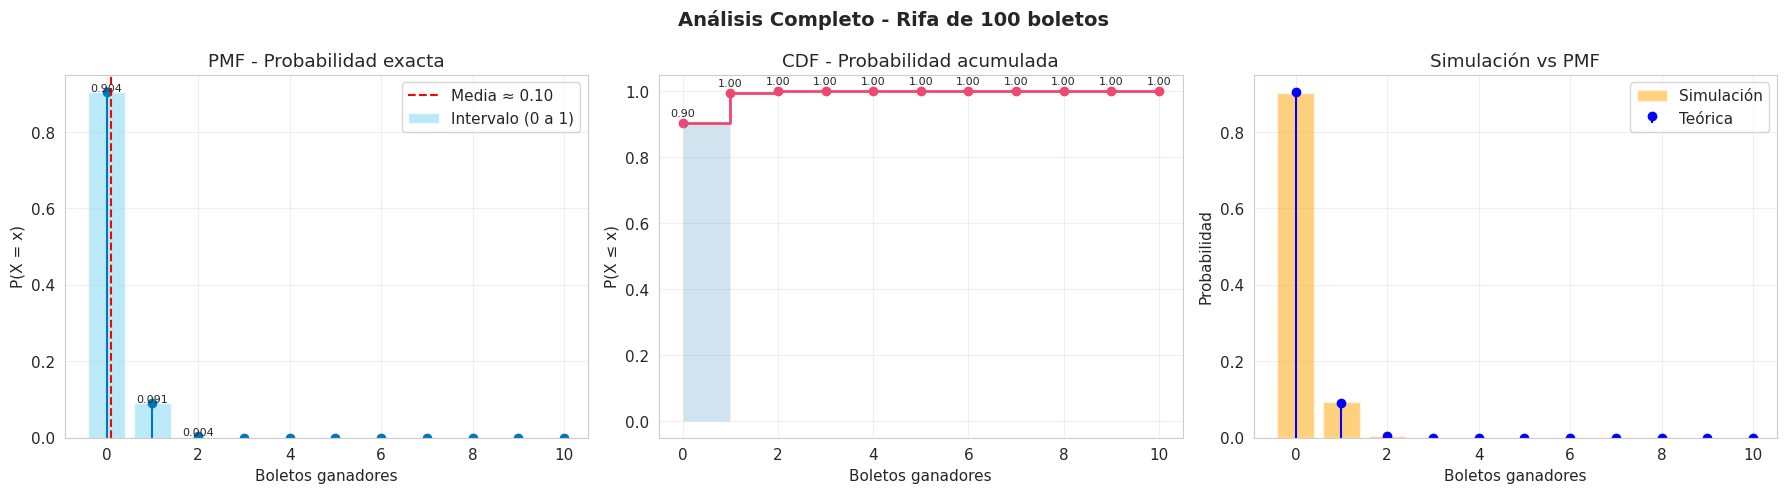

In [ ]:
# ==============================
# GRAFICAS UNIFICADAS
# ==============================
fig, axes = plt.subplots(1, 3, figsize=(18,5))

# ==============================
# 1. PMF
# ==============================

axes[0].stem(x, pmf, basefmt=" ", linefmt='#0077b6', markerfmt='o')

# Línea de la media
axes[0].axvline(media, color='red', linestyle='--', label=f"Media ≈ {media:.2f}")

# Intervalo importante (0 a 1 boletos ganadores, que es lo lógico en rifa)
mask = (x >= 0) & (x <= 1)
axes[0].bar(x[mask], pmf[mask], color='#90dbf4', alpha=0.6, label="Intervalo (0 a 1)")

axes[0].set_title("PMF - Probabilidad exacta")
axes[0].set_xlabel("Boletos ganadores")
axes[0].set_ylabel("P(X = x)")
axes[0].grid(alpha=0.3)
axes[0].legend()

# Ajuste de texto (valores pequeños)
for i, v in enumerate(pmf):
    if v > 0.001:
        axes[0].text(x[i], v+0.001, f"{v:.3f}", ha='center', fontsize=8)


# ==============================
# 2. CDF
# ==============================

axes[1].step(x, cdf, where='post', color='#ef476f', linewidth=2)
axes[1].scatter(x, cdf, color='#ef476f')

# Área acumulada (hasta 1 boleto ganador)
axes[1].fill_between(x[x<=1], cdf[x<=1], step='post', alpha=0.2)

axes[1].set_title("CDF - Probabilidad acumulada")
axes[1].set_xlabel("Boletos ganadores")
axes[1].set_ylabel("P(X ≤ x)")
axes[1].grid(alpha=0.3)

for i, v in enumerate(cdf):
    axes[1].text(x[i], v+0.02, f"{v:.2f}", ha='center', fontsize=8)


# ==============================
# 3. SIMULACIÓN vs TEÓRICA
# ==============================

axes[2].bar(valores, freq, alpha=0.5, color='orange', label="Simulación")
axes[2].stem(x, pmf, basefmt=" ", linefmt='blue', markerfmt='bo', label="Teórica")

axes[2].set_title("Simulación vs PMF")
axes[2].set_xlabel("Boletos ganadores")
axes[2].set_ylabel("Probabilidad")
axes[2].grid(alpha=0.3)
axes[2].legend()


# ==============================
# TÍTULO GENERAL
# ==============================

plt.suptitle("Análisis Completo - Rifa de 100 boletos",
             fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

# **Interpretación de lo Resultados Obtenidos**

La variable aleatoria X representa el número de boletos ganadores que obtiene una persona al comprar 10 boletos en una rifa donde solo existe 1 boleto ganador entre 100. Dado que la probabilidad de ganar con un boleto es muy baja (p=0.01), la media obtenida (μ=0.1) indica que, en promedio, una persona gana solo una décima parte de un boleto, lo que en la práctica significa que lo más probable es no ganar ningún premio.

Al analizar la PMF, se observa que la mayor probabilidad está concentrada en X=0, lo que confirma que el evento más común es no obtener ningún boleto ganador. La probabilidad de obtener exactamente un boleto ganador es muy pequeña, y la de obtener más de uno es prácticamente nula. Esto se debe a que la probabilidad individual de éxito es muy baja y el número de ensayos no es suficientemente grande como para compensarlo.

La CDF muestra que la probabilidad acumulada de obtener como máximo 1 boleto ganador es casi igual a 1, lo que indica que es extremadamente raro obtener más de un premio. Esto refuerza la idea de que el experimento está fuertemente sesgado hacia resultados bajos.

Finalmente, la comparación entre la simulación y la PMF teórica demuestra que los resultados experimentales coinciden con el modelo matemático. Esto valida el uso de la distribución binomial para representar este tipo de situaciones, donde hay muchos intentos con baja probabilidad de éxito.

# **Trabajo Autonomo: Elian Jimenez**

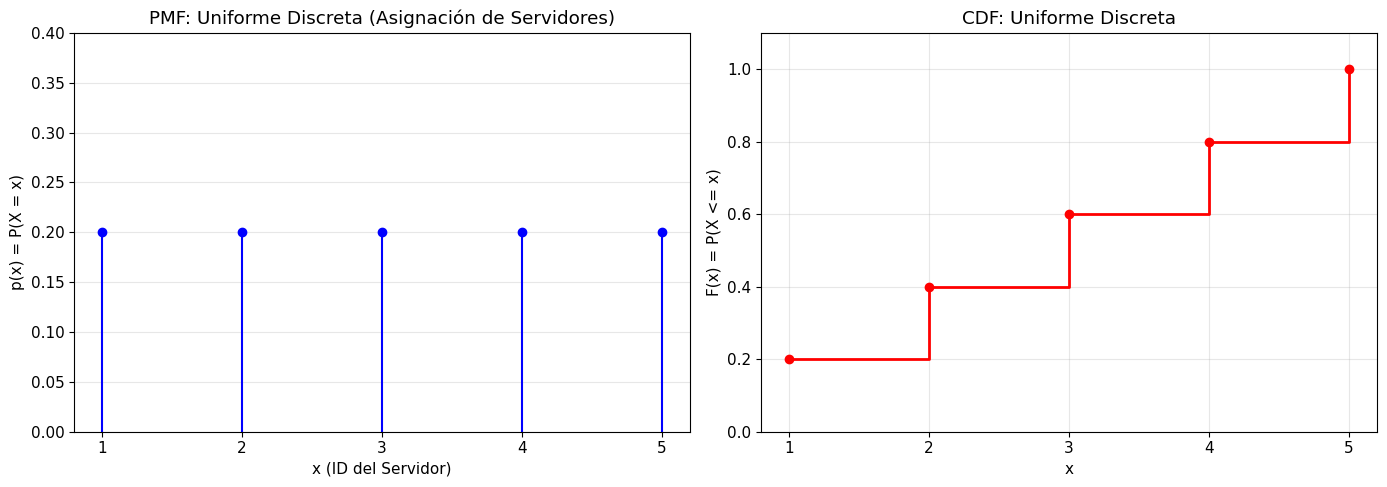

--- Interpretación de Resultados ---
1. P(X = 3) = 0.2000
Interpretación: Al tener 5 servidores con la misma carga, hay exactamente un 20% de probabilidad de que una petición cualquiera sea procesada por el servidor número 3.

2. P(X <= 2) = 0.4000
Interpretación: Existe un 40% de probabilidad acumulada de que el tráfico de red se dirija a uno de los dos primeros servidores del clúster.

3. P(X > 4) = 0.2000
Interpretación: Hay un 20% de probabilidad de que la petición caiga en el último servidor disponible (el Servidor 5).


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import randint

# Configuración de estilo
plt.rcParams["figure.figsize"] = (12, 5)
plt.rcParams["font.size"] = 11

# Definición de la Variable Aleatoria Discreta - Distribución Uniforme Discreta
# Contexto: Un balanceador de carga asigna una petición web entrante a uno de
# 5 servidores disponibles (1, 2, 3, 4, 5) con exactamente la misma probabilidad.
# X = ID del servidor asignado.

low = 1
high = 6 # En la función randint de scipy, el límite superior es exclusivo

# Valores posibles que puede tomar X (1, 2, 3, 4, 5)
x_valores = np.arange(low, high)

# PMF: Función de Masa de Probabilidad
pmf_uniforme = randint.pmf(x_valores, low, high)

# CDF: Función de Distribución Acumulada
cdf_uniforme = randint.cdf(x_valores, low, high)

# 1. Visualización PMF y CDF
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Gráfica PMF
axes[0].stem(x_valores, pmf_uniforme, basefmt=" ", linefmt='b-', markerfmt='bo')
axes[0].set_xlabel('x (ID del Servidor)')
axes[0].set_ylabel('p(x) = P(X = x)')
axes[0].set_title('PMF: Uniforme Discreta (Asignación de Servidores)')
axes[0].set_xticks(x_valores)
axes[0].set_ylim(0, 0.4)
axes[0].grid(axis='y', alpha=0.3)

# Gráfica CDF
axes[1].step(x_valores, cdf_uniforme, where='post', color='red', linewidth=2)
axes[1].scatter(x_valores, cdf_uniforme, color='red', zorder=5)
axes[1].set_xlabel('x')
axes[1].set_ylabel('F(x) = P(X <= x)')
axes[1].set_title('CDF: Uniforme Discreta')
axes[1].set_xticks(x_valores)
axes[1].set_ylim(0, 1.1)
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

# 2. Cálculo de probabilidades específicas e Interpretación
print("--- Interpretación de Resultados ---")

# a) P(X = 3): Probabilidad de que la petición se asigne al servidor 3
prob_3 = randint.pmf(3, low, high)
print(f"1. P(X = 3) = {prob_3:.4f}")
print("Interpretación: Al tener 5 servidores con la misma carga, hay exactamente un 20% de probabilidad de que una petición cualquiera sea procesada por el servidor número 3.\n")

# b) P(X <= 2): Probabilidad de que se asigne a los servidores 1 o 2
prob_menor_igual_2 = randint.cdf(2, low, high)
print(f"2. P(X <= 2) = {prob_menor_igual_2:.4f}")
print("Interpretación: Existe un 40% de probabilidad acumulada de que el tráfico de red se dirija a uno de los dos primeros servidores del clúster.\n")

# c) P(X > 4): Probabilidad de que se asigne a un servidor con ID mayor a 4
prob_mayor_4 = 1 - randint.cdf(4, low, high)
print(f"3. P(X > 4) = {prob_mayor_4:.4f}")
print("Interpretación: Hay un 20% de probabilidad de que la petición caiga en el último servidor disponible (el Servidor 5).")

#**Trabajo Autonomo: Christopher Pineda**

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import binom

# ==============================
# PARTE 1: DEFINICIÓN DEL MODELO
# ==============================

# Contexto:
# X = número de caras obtenidas en 25 lanzamientos de una moneda justa

n = 25   # número total de lanzamientos (ensayos) - Ajustado a 25
p = 0.5  # probabilidad de éxito (obtener cara)

# Generamos todos los valores posibles de la variable aleatoria (0 a 25)
x = np.arange(0, n+1)

# ==============================
# CÁLCULO DE FUNCIONES
# ==============================

# PMF: Probabilidad de cada valor exacto P(X = x)
pmf = binom.pmf(x, n, p)

# CDF: Probabilidad acumulada P(X ≤ x)
cdf = binom.cdf(x, n, p)

# ==============================
# MEDIDAS ESTADÍSTICAS
# ==============================

media = n * p
varianza = n * p * (1 - p)
desviacion = np.sqrt(varianza)

print("Valores posibles:", x)
print("\nMedia (Esperanza):", round(media, 2))
print("Varianza:", round(varianza, 2))
print("Desviación estándar:", round(desviacion, 2))

# ==============================
# PARTE 2: CÁLCULO DE PROBABILIDADES
# ==============================

# 1. Probabilidad exacta: exactamente 12 caras
p1 = binom.pmf(12, n, p)

# 2. Probabilidad acumulada: obtener 10 caras o menos
p2 = binom.cdf(10, n, p)

# 3. Probabilidad en intervalo: entre 10 y 15 caras
p3 = binom.cdf(15, n, p) - binom.cdf(9, n, p)

# 4. Probabilidad de valores altos: más de 18 caras
p4 = 1 - binom.cdf(18, n, p)

# 5. Probabilidad de no obtener ninguna cara (0 de 25)
p5 = binom.pmf(0, n, p)

# 6. Probabilidad de obtener al menos una cara
p6 = 1 - p5

# 7. Probabilidad de eventos extremos (20 a 25 caras)
p7 = binom.cdf(25, n, p) - binom.cdf(19, n, p)

# 8. Probabilidad alrededor de la media (12 a 13 caras)
p8 = binom.cdf(13, n, p) - binom.cdf(11, n, p)

print("\n--- PROBABILIDADES ---")
print(f"P(X = 12) = {p1:.4f}")
print(f"P(X ≤ 10) = {p2:.4f}")
print(f"P(10 ≤ X ≤ 15) = {p3:.4f}")
print(f"P(X > 18) = {p4:.4f}")
print(f"P(X = 0) = {p5:.4f}")
print(f"P(X ≥ 1) = {p6:.4f}")
print(f"P(20 ≤ X ≤ 25) = {p7:.4f}")
print(f"P(12 ≤ X ≤ 13) = {p8:.4f}")

Valores posibles: [ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23
 24 25]

Media (Esperanza): 12.5
Varianza: 6.25
Desviación estándar: 2.5

--- PROBABILIDADES ---
P(X = 12) = 0.1550
P(X ≤ 10) = 0.2122
P(10 ≤ X ≤ 15) = 0.7705
P(X > 18) = 0.0073
P(X = 0) = 0.0000
P(X ≥ 1) = 1.0000
P(20 ≤ X ≤ 25) = 0.0020
P(12 ≤ X ≤ 13) = 0.3100


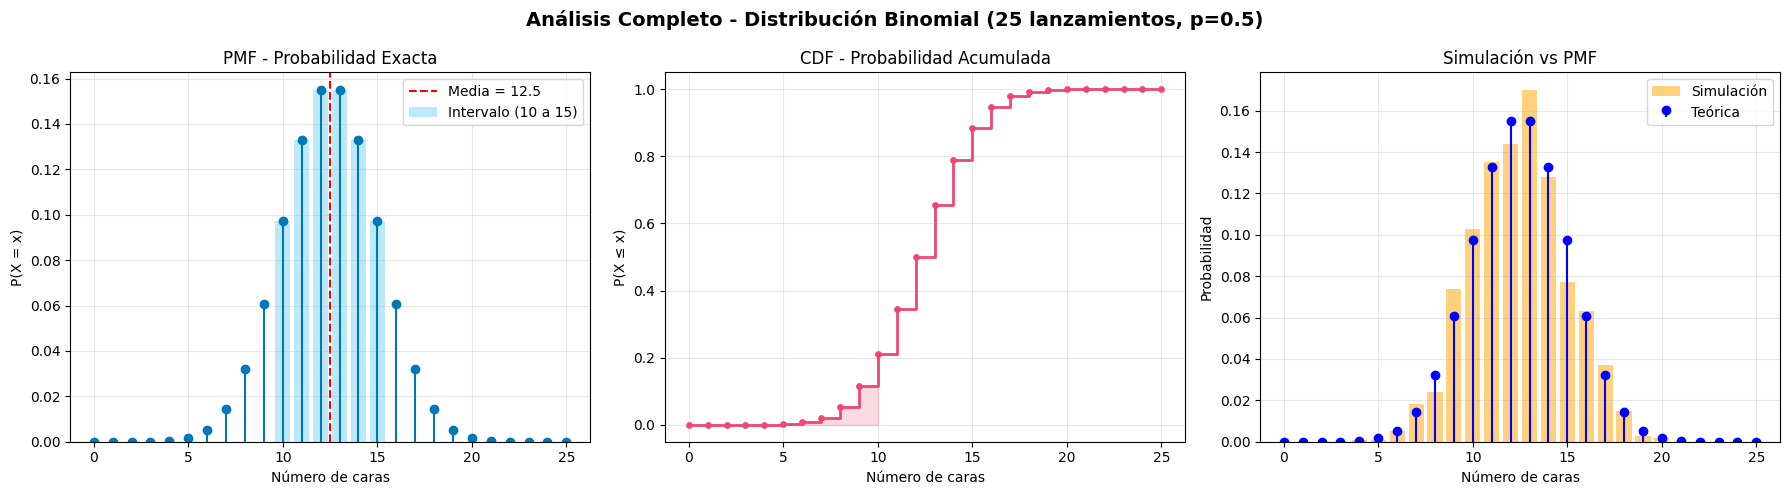

In [ ]:
# ==============================
# GRÁFICAS UNIFICADAS
# ==============================

# Simulación para la tercera gráfica
simulacion = binom.rvs(n, p, size=1000)
valores, counts = np.unique(simulacion, return_counts=True)
freq = counts / 1000

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1. PMF
axes[0].stem(x, pmf, basefmt=" ", linefmt='#0077b6', markerfmt='o')
axes[0].axvline(media, color='red', linestyle='--', label=f"Media = {media}")
# Resaltar intervalo de 10 a 15
mask = (x >= 10) & (x <= 15)
axes[0].bar(x[mask], pmf[mask], color='#90dbf4', alpha=0.6, label="Intervalo (10 a 15)")
axes[0].set_title("PMF - Probabilidad Exacta")
axes[0].set_xlabel("Número de caras")
axes[0].set_ylabel("P(X = x)")
axes[0].grid(alpha=0.3)
axes[0].legend()

# 2. CDF
axes[1].step(x, cdf, where='post', color='#ef476f', linewidth=2)
axes[1].scatter(x, cdf, color='#ef476f', s=15)
axes[1].fill_between(x[x<=10], cdf[x<=10], step='post', alpha=0.2, color='#ef476f')
axes[1].set_title("CDF - Probabilidad Acumulada")
axes[1].set_xlabel("Número de caras")
axes[1].set_ylabel("P(X ≤ x)")
axes[1].grid(alpha=0.3)

# 3. SIMULACIÓN vs TEÓRICA
axes[2].bar(valores, freq, alpha=0.5, color='orange', label="Simulación")
axes[2].stem(x, pmf, basefmt=" ", linefmt='blue', markerfmt='bo', label="Teórica")
axes[2].set_title("Simulación vs PMF")
axes[2].set_xlabel("Número de caras")
axes[2].set_ylabel("Probabilidad")
axes[2].grid(alpha=0.3)
axes[2].legend()

plt.suptitle("Análisis Completo - Distribución Binomial (25 lanzamientos, p=0.5)", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## Interpretacion
La variable modela el número de caras en 25 lanzamientos, con una media de 12.5 que indica una distribución simétrica. Los resultados se concentran entre 10 y 15 caras ($P \approx 0.77$), mientras que obtener valores extremos (como 0 o más de 20) es estadísticamente improbable.La CDF muestra una acumulación rápida de probabilidad en los valores centrales, facilitando el análisis de rangos. La simulación con 1000 datos valida el modelo, confirmando que los resultados prácticos coinciden con la teoría matemática de la distribución binomial.